In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from scholarlm.utils import (
    get_filenames_in_directory,
    load_and_process_results
)

%load_ext autoreload
%autoreload 2

INFO 03-18 10:40:54 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 03-18 10:41:08 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


In [2]:
palette = sns.color_palette("husl", 8)
cmap = ListedColormap(palette)

cluster_color_dict = {i: cmap(7 - i) for i in range(8)}
cluster_color_dict[-1] = 'grey'

color_dict = {'pond' : cmap(5), 'lake': cmap(1), 'wetland': cmap(7), 'other' : cmap(6)}

# This assumes tex is installed in your system, 
# if not, you may simply remove most of this, aside from font.size 
# (doing so, however, will break certain plotting functions)
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "font.serif": [],
    "text.usetex": True,
    "pgf.rcfonts": False,
    "font.size": 20
})

In [3]:
# For converting the various ecosystem labels in the dataset to a standardized set of labels:
# (pond, lake, wetland, other)
classification_dict = {
    'pond' : 'pond',
    'lake' : 'lake',
    'wetland' : 'wetland',
    'small water bodies or ponds' : 'pond',
    'pond or small lake' : 'pond',
    'wetland vs. lake' : None,
    'lakes' : 'lake',
    'shallow lake' : 'lake',
    'urban ponds' : 'pond',
    'shallow lakes' : 'lake',
    'karst pond' : 'pond',
    'small lake' : 'lake',
    'pothole' : 'other',
    'pools and ponds; bodri (italian term)' : 'pond',
    'temporary pond' : 'pond',
    'stormwater pond' : 'pond',
    'karst ponds' : 'pond',
    'subtropical shallow lake' : 'lake',
    'small lakes' : 'lake',
    'treatment cells in constructed wetlands' : 'wetland',
    'kettle hole' : 'other',
    'pond or reservoir' : 'pond',
    'lentic small water bodies' : 'pond',
    'pool' : 'other',
    'zbiornik(pond)' : 'pond',
    'permenant pond' : 'pond',
    'rock pools' : 'other',
    'dune ponds' : 'pond',
    'farm pond; small impoundment' : 'pond',
    'farm pond' : 'pond',
    'mediterranean wetland' : 'wetland',
    'small humic lakes' : 'lake',
    'high planktivory lake' : 'lake',
    'inland-lake' : 'lake',
    'pond/tundra pond' : 'pond',
    'lakes and reservoirs (broken into small and large)' : 'lake',
    'wetland' : 'wetland',
    'small (< 10 km2) seasonally ice-covered arctic lakes' : 'lake',
    'wetland; pond' : None,
    'peat lake' : 'lake',
    'small tropical lake' : 'lake',
    'meteorite crater ponds' : 'pond',
    'agricultural water reservoir' : 'pond',
    'coastal plain shallow lake' : 'lake',
    'residential pond' : 'pond',
    'small impoundment' : 'other',
    'small-sized lentic ecosystem; lake' : None,
    'reservoir' : 'other',
    'small acidic bog lake' : 'lake',
    'in-field pond' : 'pond',
    'temporary lake' : 'lake',
    'lake (reservoir)' : 'lake',
    'shallow subtropical lake' : 'lake',
    'wetland/lake' : None,
    'vernal pool' : 'other',
    'temporary lake/seasonal pond' : None,
    'permanent lake' : 'lake',
    'other' : 'other',
    'ponds' : 'pond',
    'deep refuge lake' : 'lake',
    'lake/pond' : None,
    'lagoon; shallow lake' : 'lake',
    'marsh' : 'wetland',
    'terporary wetland; also temparary pond' : None,
    'aquatic environment' : 'other',
    'near-natural ponds' : 'pond',
    'small-sized lentic ecosystem; wetland' : None,
    'reservoir' : 'other',
    'vernal pool' : 'other',
    'bog' : 'other',
    'impoundment' : 'other',
    'shallow lake' : 'lake',
    'river branch' : 'other',
    'basin' : 'other',
    'stream' : 'other',
    'constructed wetland' : 'wetland',
    'groundwater' : 'other',
    'watershed' : 'other',
    'river' : 'other',
    'brackish-water body' : 'other',
    'channel' : 'other',
    'peatland complex' : 'other',
    'peatland' : 'other',
    'permanent freshwater marsh' : 'wetland',
    'lagoon' : 'other'
}

### Load Manually Extracted Data

In [4]:
pond_df = pd.read_csv(
    "../data/pond/pond_data_corrected.csv",
    encoding_errors='ignore',
    index_col = 0
)
pond_df = pond_df.reset_index(drop=True)

id_cols = ['author', 'title', 'name', 'location', 'ecosystem', 'date', 'state']
pond_df[id_cols] = pond_df[id_cols].fillna('NA')

pond_df = pd.pivot_table(
    pond_df,
    index=id_cols,
    columns='attribute',
    values='value',
    aggfunc='first'
)

# Convert m2 to ha (what the external dataset uses)
pond_df['surface_area'] = pond_df['surface_area'] / 10000

# convert veg cover from percentage to proportion
pond_df['vegetation_cover'] = pond_df['vegetation_cover'] / 100

pond_df.dropna(axis=0, how='all', inplace=True)

pond_data = pond_df.to_numpy()
pond_labels = pond_df.index.get_level_values('ecosystem').map(classification_dict).to_numpy()

In [5]:
len(pond_data), len(pond_labels)

(1207, 1207)

### Load LLM Extracted Data

In [57]:
# ---------------------------------
# Load experiment results
# ---------------------------------

experiment_data_path = "../data/experiments/2026_03_04/pond_judged_combined_scores.json"

unit_conversion_table = {
    'max_depth': {"cm": 0.01, "feet": 0.3048, "km": 1000, "m": 1},
    'surface_area': {"km^2": 100, "ha": 1, "mi^2": 258.999, "m^2": 1e-4, "acres": 0.40486},
    'vegetation_cover': {"percent": 1/100, "fraction": 1.0},
    'tn': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 14.01, "ppm": 1000.0, "ppb": 1.0},
    'tp': {"mg/L": 1000.0, "µg/L": 1.0, "μmol/L": 30.97, "ppm": 1000.0, "ppb": 1.0},
    'chla': {"mg/L": 1000.0, "µg/L": 1.0, "mg/m^3": 1.0},
    'ph': {},
    'latitude': {},
    'longitude': {}
}

attribute_types = {
    'max_depth': float,
    'surface_area': float,
    'vegetation_cover': float,
    'tn': float,
    'tp': float,
    'chla': float,
    'ph': float,
    'latitude': float,
    'longitude': float
}

# NOTE: some of these things you should get rid of in your extraction process!
drop_keys = ["feature_terms", "attribute_terms", "abbreviations", "table_logprob", "page_logprob", "judgement_raw_text"]
drop_attrs = ['latitude', 'longitude']

extracted_df = load_and_process_results(
    json_path=experiment_data_path,
    unit_conversion_table=unit_conversion_table,
    attribute_types=attribute_types,
    drop_keys=drop_keys,
    drop_attrs=drop_attrs,
    attribute_col="attribute",
    value_col="value",
    unit_col="units",
    out_col="processed_value",
    strict_unit_conversion=True
)


#extracted_df_scores = np.load("../data/experiments/2026_03_04/pond_judged_combined_scores.npy")
#extracted_df['confidence'] = extracted_df_scores

id_cols = ["entity_id", "ecosystem"]
extracted_data_df = pd.pivot_table(
    extracted_df,
    index=id_cols,
    columns="attribute",
    values="processed_value",
    aggfunc='first'
)


extracted_confidence_df = pd.pivot_table(
    extracted_df,
    index=id_cols,
    columns="attribute",
    values="confidence",
    aggfunc='first'
)


duplicate_mask = extracted_data_df.duplicated(keep="first")
extracted_data_df = extracted_data_df[~duplicate_mask]
extracted_confidence_df = extracted_confidence_df[~duplicate_mask]

pond_extracted_data = extracted_data_df.to_numpy()
pond_extracted_labels = extracted_data_df.index.get_level_values('ecosystem').map(classification_dict).to_numpy()
pond_extracted_confidence = extracted_confidence_df.prod(axis=1, skipna = True).to_numpy()

pond_extracted_idx = [i for i, label in enumerate(pond_extracted_labels) if label in ['pond', 'lake', 'wetland']]
pond_extracted_data = pond_extracted_data[pond_extracted_idx]
pond_extracted_labels = pond_extracted_labels[pond_extracted_idx]
pond_extracted_confidence = pond_extracted_confidence[pond_extracted_idx]

# Filter low confidence points
'''
confidence_threshold = 0.75
high_confidence_mask = pond_extracted_confidence >= confidence_threshold
pond_extracted_data = pond_extracted_data[high_confidence_mask]
pond_extracted_labels = pond_extracted_labels[high_confidence_mask]
pond_extracted_confidence = pond_extracted_confidence[high_confidence_mask]
'''

'\nconfidence_threshold = 0.75\nhigh_confidence_mask = pond_extracted_confidence >= confidence_threshold\npond_extracted_data = pond_extracted_data[high_confidence_mask]\npond_extracted_labels = pond_extracted_labels[high_confidence_mask]\npond_extracted_confidence = pond_extracted_confidence[high_confidence_mask]\n'

In [43]:
len(pond_extracted_data), len(pond_extracted_labels), len(pond_extracted_confidence)

(1351, 1351, 1351)

### Other Data
Since the original paper also includes publically available lake and wetland data, we
include this for our analysis as well.

In [58]:
lake_df = pd.read_csv('../data/pond/external/nla12_keyvariables_data.csv')
lake_physical = pd.read_csv('../data/pond/external/nla2012_wide_phabmet_10202016.csv')
lake_chemical = pd.read_csv('../data/pond/external/nla2012_waterchem_wide.csv')

veg_covers = []
for idt in lake_df.UID:
    res = lake_physical.loc[lake_physical.UID == idt, 'AMFCALL'].values
    #res = lake_physical.loc[lake_physical.UID == idt, 'AMFCEMERGENT'].values
    if len(res) == 1:
        veg_covers.append(res[0])
    else:
        veg_covers.append(np.nan)
lake_df['veg_cover'] = veg_covers

phs = []
for idt in lake_df.UID:
    res = lake_chemical.loc[lake_chemical.UID == idt, 'PH_RESULT'].values
    if len(res) == 1:
        phs.append(res[0])
    else:
        phs.append(np.nan)
lake_df['pH'] = phs

select_features = ['AREA_HA', 'INDEX_SITE_DEPTH', 'veg_cover', 'NTL_RESULT', 'PTL_RESULT', 'CHLX_RESULT', 'pH']
select_features = ["CHLX_RESULT", "INDEX_SITE_DEPTH", "pH", "AREA_HA", "NTL_RESULT", "PTL_RESULT", "veg_cover"]
sub_lake_df = lake_df.loc[:, select_features]
sub_lake_df.columns = ["chla", "max_depth", "ph", "surface_area", "tn", "tp", "vegetation_cover"]

# Convert from mg/L to ug/L
sub_lake_df['tn'] = sub_lake_df['tn'] * 1000

sub_lake_df.dropna(axis=0, how='all', inplace=True)

lake_data = sub_lake_df.to_numpy()
lake_labels = np.array(['lake'] * lake_data.shape[0])

In [59]:
wetland_df = pd.read_csv('../data/pond/external/nwca2011_aachar.csv')
wetland_vegetation = pd.read_csv('../data/pond/external/nwca2011_vegmetrics.csv')
wetland_chemical = pd.read_csv('../data/pond/external/nwca2011_waterchem.csv')
wetland_chl = pd.read_csv('../data/pond/external/nwca2011_chla.csv')

depths = []
veg_covers = []
tns = []
tps = []
chls = []
phs = []
for uid in wetland_df.UID:
    res = wetland_vegetation.loc[wetland_vegetation.UID == uid, 'MAX_H2O_DEPTH'].values
    if len(res) == 1:
        depths.append(res[0])
    else:
        depths.append(np.nan)
    
    #res = wetland_vegetation.loc[wetland_vegetation.UID == uid, 'XCOV_H2O_EMERGVEG'].values
    res = wetland_vegetation.loc[wetland_vegetation.UID == uid, 'XCOV_H2O_NOVEG'].values
    if len(res) == 1:
        #veg_covers.append(res[0])
        veg_covers.append(100 - res[0])
    else:
        veg_covers.append(np.nan)
    
    res = wetland_chemical.loc[wetland_chemical.UID == uid, 'TN'].values
    if len(res) == 1:
        tns.append(res[0])
    else:
        tns.append(np.nan)
    
    res = wetland_chemical.loc[wetland_chemical.UID == uid, 'TP'].values
    if len(res) == 1:
        tps.append(res[0])
    else:
        tps.append(np.nan)
    
    res = wetland_chl.loc[wetland_chl.UID == uid, 'CHLA'].values
    if len(res) == 1:
        chls.append(res[0])
    else:
        chls.append(np.nan)
    
    res = wetland_chemical.loc[wetland_chemical.UID == uid, 'PH'].values
    if len(res) == 1:
        phs.append(res[0])
    else:
        phs.append(np.nan)

wetland_df['surface_area'] = np.nan
wetland_df['depth'] = depths
wetland_df['veg_cover'] = veg_covers
wetland_df['TN'] = tns
wetland_df['TP'] = tps
wetland_df['chl_a'] = chls
wetland_df['pH'] = phs

select_features = ["chl_a", "depth", "pH", "surface_area", "TN", "TP", "veg_cover"]
sub_wetland_df = wetland_df.loc[:, select_features]
sub_wetland_df.columns = ["chla", "depth", "ph", "surface_area", "tn", "tp", "vegetation_cover"]

# Convert from cm to m
# NOTE: I'm just guessing this was originally in cm, since depths are very large otherwise
sub_wetland_df['depth'] = sub_wetland_df['depth'] / 100

# Convert from percent to proportion
sub_wetland_df['vegetation_cover'] = sub_wetland_df['vegetation_cover'] / 100

# Convert from mg/L to ug/L
sub_wetland_df['tn'] = sub_wetland_df['tn'] * 1000

sub_wetland_df.dropna(axis=0, how='all', inplace=True)

wetland_data = sub_wetland_df.to_numpy()
wetland_labels = np.array(['wetland'] * wetland_data.shape[0])

### Data Visualization

In [60]:
data = np.concatenate([pond_data, lake_data, wetland_data], axis=0)
labels = np.concatenate([pond_labels, lake_labels, wetland_labels], axis=0)

extracted_data = np.concatenate([pond_extracted_data, lake_data, wetland_data], axis=0)
extracted_labels = np.concatenate([pond_extracted_labels, lake_labels, wetland_labels], axis=0)
extracted_confidence = np.concatenate([pond_extracted_confidence, np.ones(lake_data.shape[0] + wetland_data.shape[0])], axis=0)

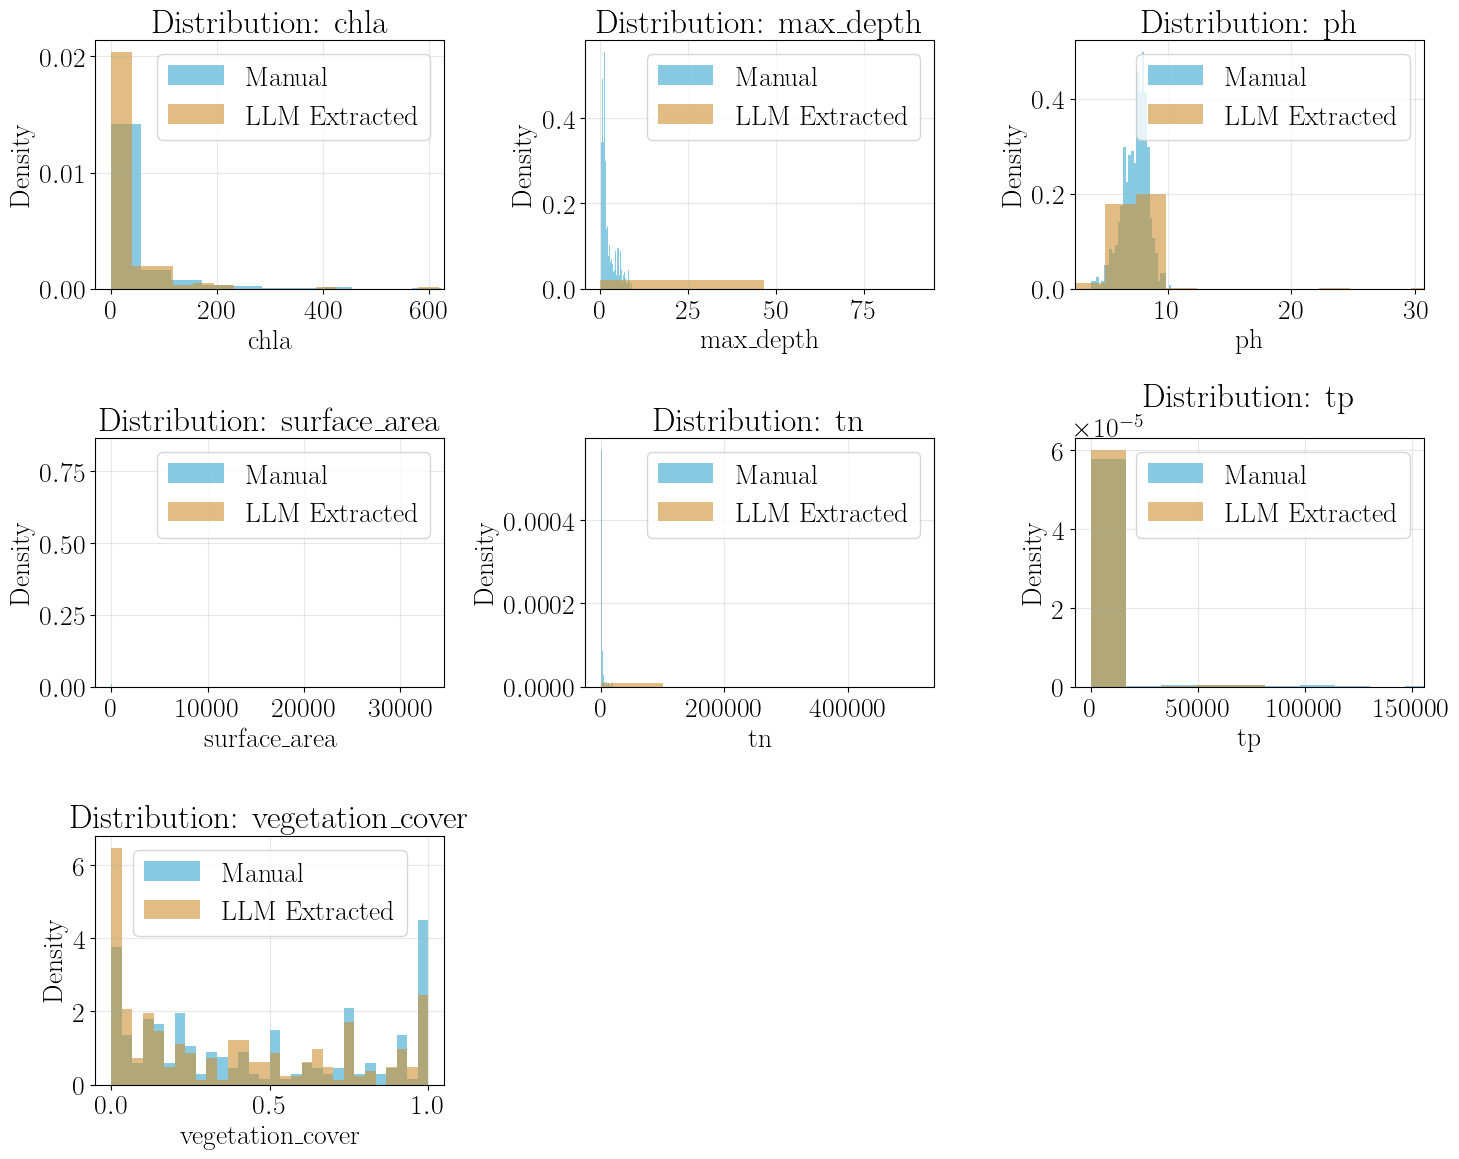

In [75]:
# Get feature names
feature_names = pond_df.columns.tolist()

# Create subplots for each feature
num_features = len(feature_names)
ncols = 3
nrows = (num_features + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for idx, feature in enumerate(feature_names):
    ax = axes[idx]
    
    # Extract feature column from both datasets
    col_idx = idx
    manual_feature = pond_data[:, col_idx]
    extracted_feature = pond_extracted_data[:, col_idx]
    
    # Remove NaN values
    manual_feature_clean = manual_feature[~np.isnan(manual_feature)]
    extracted_feature_clean = extracted_feature[~np.isnan(extracted_feature)]
    
    # Plot histograms
    ax.hist(manual_feature_clean, bins=30, alpha=0.6, label='Manual', color=color_dict['pond'], density=True)
    ax.hist(extracted_feature_clean, bins=30, alpha=0.6, label='LLM Extracted', color=color_dict['lake'], density=True)
    
    # Set x-axis limits based on percentiles to handle outliers
    combined_clean = np.concatenate([manual_feature_clean, extracted_feature_clean])
    p1, p99 = np.percentile(combined_clean, [1, 99])
    # Add a small margin
    margin = (p99 - p1) * 0.05
    ax.set_xlim(p1 - margin, p99 + margin)
    
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.set_title(f'Distribution: {feature}')
    ax.legend()
    ax.grid(alpha=0.3)

# Hide unused subplots
for idx in range(num_features, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [65]:
idx = 5
print("Feature:", feature_names[idx])
print(np.nanmin(pond_data[:, idx]), np.nanmax(pond_data[:, idx]), np.nanmean(pond_data[:, idx]))
print(np.nanmin(pond_extracted_data[:, idx]), np.nanmax(pond_extracted_data[:, idx]), np.nanmean(pond_extracted_data[:, idx]))

Feature: tp
3.2 490000.0 7051.631932059448
2.0 490000.0 2685.189296636086


In [66]:
np.nanmin(pond_extracted_data[:, 0]), np.nanmax(pond_extracted_data[:, 0]), np.nanmean(pond_extracted_data[:, 0])

(0.0, 1160.0, 40.571000000000005)

In [67]:
# Standard scaling
scaler = StandardScaler()
cleaned_data = scaler.fit_transform(data)
cleaned_extracted_data = scaler.fit_transform(extracted_data)

# Impute missing values
imputer = KNNImputer(n_neighbors=5)
cleaned_data = imputer.fit_transform(cleaned_data)
cleaned_extracted_data = imputer.fit_transform(cleaned_extracted_data)

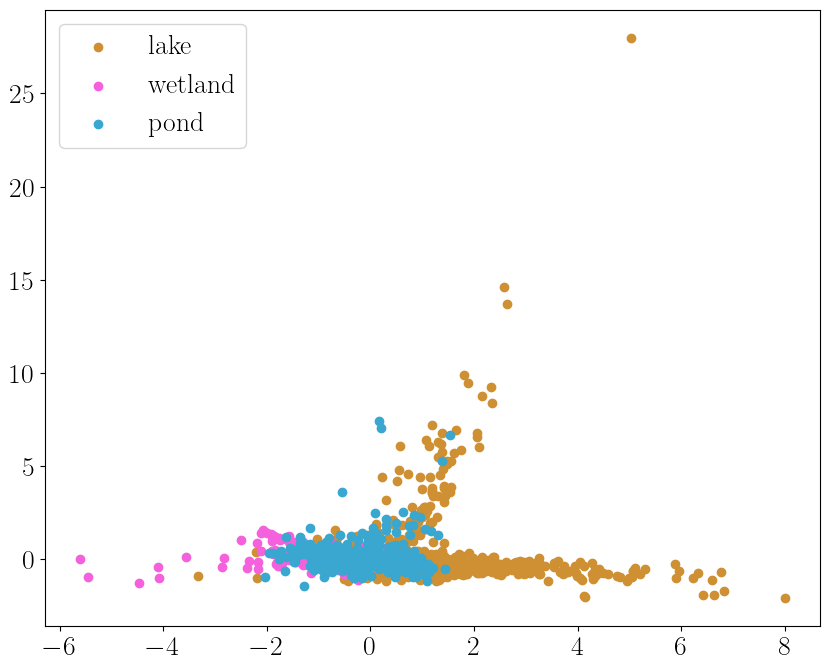

In [68]:
pca = PCA(n_components=2)
data_dim = pca.fit_transform(cleaned_data)

fig, ax = plt.subplots(figsize=(10, 8))
for ecotype in ['lake', 'wetland','pond']:
    idx = labels == ecotype
    ax.scatter(data_dim[idx,0], data_dim[idx,1], label=ecotype, color=color_dict[ecotype])

plt.legend()

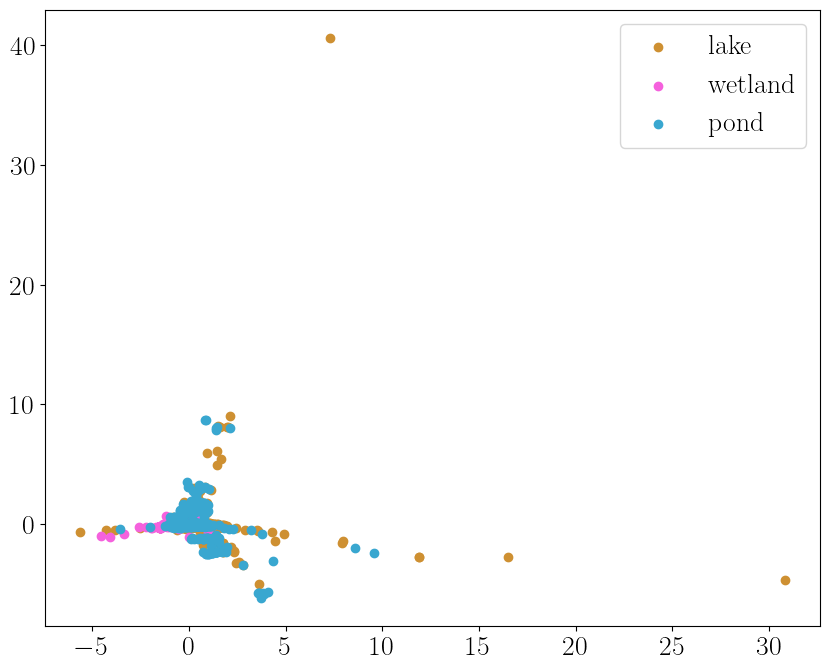

In [69]:
extracted_data_dim = pca.transform(cleaned_extracted_data)

fig, ax = plt.subplots(figsize=(10, 8))
for ecotype in ['lake', 'wetland','pond']:
    idx = extracted_labels == ecotype
    ax.scatter(extracted_data_dim[idx,0], extracted_data_dim[idx,1], label=ecotype, color=color_dict[ecotype])

plt.legend()

### Clustering

In [70]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import numpy as np

def centroid_matching_distance(A, B, labels_a, labels_b, points_a, points_b, metric='euclidean'):
    """
    A, B:       arrays of shape (k, d) and (m, d) — cluster centers
    labels_a/b: array of cluster assignments for each point
    points_a/b: array of shape (n, d) — original data points
    metric:     distance metric to use
    
    Returns:
        raw_dist:   mean matched distance
        norm_dist:  normalized by mean intra-cluster spread
        matching:   list of (i, j) center pairs
    """
    # Optimal assignment
    D = cdist(A, B, metric=metric)
    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]
    raw_dist = matched_distances.mean()

    # Mean intra-cluster spread across both clusterings
    def mean_cluster_spread(centers, labels, points):
        spreads = []
        for i, center in enumerate(centers):
            cluster_points = points[labels == i]
            if len(cluster_points) > 1:
                spreads.append(cdist(cluster_points, [center], metric=metric).mean())
        return np.mean(spreads)

    spread_a = mean_cluster_spread(A, labels_a, points_a)
    spread_b = mean_cluster_spread(B, labels_b, points_b)
    mean_spread = (spread_a + spread_b) / 2

    norm_dist = raw_dist / mean_spread

    return raw_dist, norm_dist, list(zip(row_ind, col_ind))

In [71]:
k = 3

# Baseline Clustering:
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(cleaned_data)
cluster_centers = kmeans.cluster_centers_
cluster_labels = kmeans.labels_


# Iterating over confidence threshold clusterings:
centroid_distances = []
confidence_thresholds = np.linspace(0, 0.9, 11)
for threshold in confidence_thresholds:
    high_confidence_mask = extracted_confidence >= threshold
    filtered_extracted_data = cleaned_extracted_data[high_confidence_mask]

    kmeans_extracted = KMeans(n_clusters=k, random_state=42)
    kmeans_extracted.fit(filtered_extracted_data)
    cluster_centers_extracted = kmeans_extracted.cluster_centers_
    cluster_labels_extracted = kmeans_extracted.labels_

    distance, norm_distance, matches = centroid_matching_distance(
        cluster_centers,
        cluster_centers_extracted,
        cluster_labels,
        cluster_labels_extracted,
        cleaned_data,
        filtered_extracted_data
    )
    centroid_distances.append(distance)

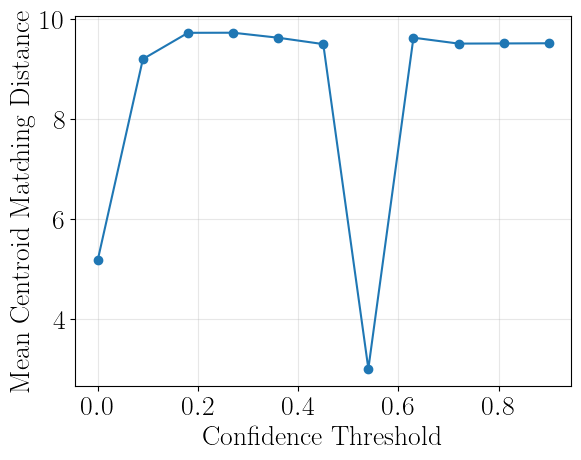

In [72]:
plt.plot(confidence_thresholds, centroid_distances, marker='o')
plt.xlabel('Confidence Threshold')
plt.ylabel('Mean Centroid Matching Distance')
plt.grid(alpha=0.3)
plt.show()

In [73]:
k = 3

# Baseline Clustering:
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(cleaned_data)
cluster_centers = kmeans.cluster_centers_
cluster_labels = kmeans.labels_


# Iterative outlier removal based on distance-to-center weighted by (1 - confidence):
centroid_distances = []
num_points_removed = []
max_removals = 100

# Start with full extracted dataset
current_extracted_data = cleaned_extracted_data.copy()
current_extracted_confidence = extracted_confidence.copy()
current_extracted_labels = extracted_labels.copy()
remaining_indices = np.arange(len(extracted_labels))

while len(current_extracted_data) > 0:
    # Perform clustering on current data
    kmeans_extracted = KMeans(n_clusters=k, random_state=42)
    kmeans_extracted.fit(current_extracted_data)
    cluster_centers_extracted = kmeans_extracted.cluster_centers_
    cluster_labels_extracted = kmeans_extracted.labels_

    # Compute distance to assigned cluster center for each point
    distances_to_center = np.array([
        np.linalg.norm(current_extracted_data[i] - cluster_centers_extracted[cluster_labels_extracted[i]])
        for i in range(len(current_extracted_data))
    ])

    # Compute weighted outlier score: distance * (1 - confidence)
    outlier_scores = distances_to_center * (1 - current_extracted_confidence)

    # Compute matching distance with baseline
    distance, norm_distance, matches = centroid_matching_distance(
        cluster_centers,
        cluster_centers_extracted,
        cluster_labels,
        cluster_labels_extracted,
        cleaned_data,
        current_extracted_data
    )
    centroid_distances.append(distance)
    num_points_removed.append(len(extracted_labels) - len(current_extracted_data))

    # Check if we've reached the removal limit
    if num_points_removed[-1] >= max_removals:
        break

    # Remove point with highest outlier score
    if len(current_extracted_data) > 0:
        max_outlier_idx = np.argmax(outlier_scores)
        current_extracted_data = np.delete(current_extracted_data, max_outlier_idx, axis=0)
        current_extracted_confidence = np.delete(current_extracted_confidence, max_outlier_idx)
        current_extracted_labels = np.delete(current_extracted_labels, max_outlier_idx)
    else:
        break

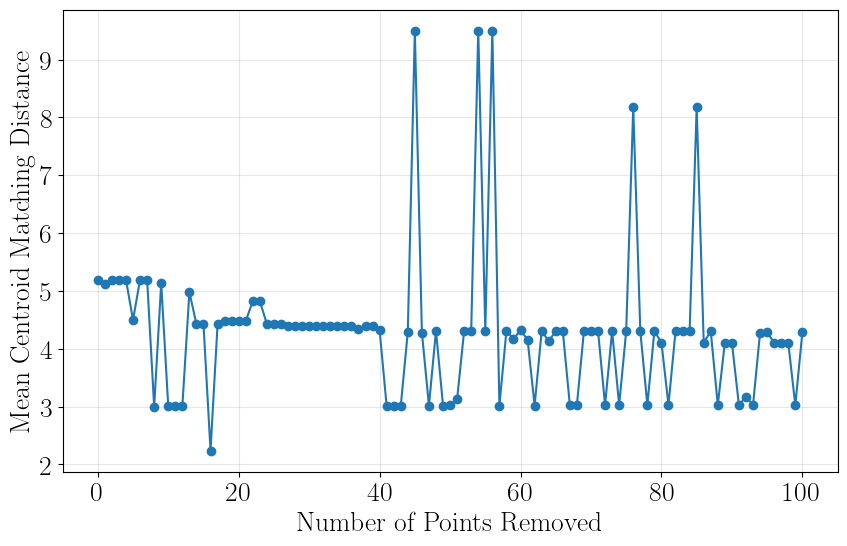

In [74]:
plt.figure(figsize=(10, 6))
plt.plot(num_points_removed, centroid_distances, marker='o')
plt.xlabel('Number of Points Removed')
plt.ylabel('Mean Centroid Matching Distance')
plt.grid(alpha=0.3)
plt.show()